# 21. How GNFW pressure-profile shape parameters shape the tSZ power spectrum

We use hmfast's standard **Arnaud (2010) GNFW** pressure profile
(`GNFWPressureProfile`) with the FLAMINGO D3A fiducial cosmology and hydrostatic
bias $B=1$. The built-in $P_{500c}(M,z)$ normalization is fixed; we vary one
**shape** parameter at a time around the A10 defaults:

$P_0,\,c_{500},\,\alpha_\mathrm{GNFW},\,\beta_\mathrm{GNFW},\,\gamma$.

The plots show the raw halo-model tSZ spectrum $D_\ell = \ell(\ell+1)C_\ell^{yy}/2\pi$
(1-halo + 2-halo).

A second section plots the GNFW **pressure profile** $P(x)$ versus $x=r/R_{500c}$ with the same parameter sweeps.

A third section projects the hmfast pressure profile to real space and plots $y(\theta)$ versus $\theta$.

A fourth section uses hmfast's `profile.u_k` (Limber multipole $u_\ell$) and the tSZ kernel to plot the single-halo Compton-$y$ harmonics $y_\ell = W_\mathrm{tSZ}(z)\,u_\ell$ versus $\ell$.

Separate panels vary the hydrostatic mass bias $B$ from 1 to 2 with the A10 GNFW shape held fixed.


In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer

# FLAMINGO D3A fiducial (same numbers as flamingo.catalogue.D3A_COSMOLOGY)
_H0, _h = 68.1, 0.681
_OMEGA_M, _OMEGA_B, _M_NCDM = 0.306, 0.0486, 0.06
_omega_b = _OMEGA_B * _h ** 2
_omega_nu = _M_NCDM / 93.14
_omega_cdm = _OMEGA_M * _h ** 2 - _omega_b - _omega_nu
COSMO = Cosmology(H0=_H0, omega_cdm=_omega_cdm, omega_b=_omega_b, m_ncdm=_M_NCDM)

B = 1.0
hm = HaloModel(cosmology=COSMO)
ell = jnp.logspace(1.3, np.log10(6000), 40)
m_grid = jnp.logspace(11.0, 15.5, 50)
z_grid = jnp.geomspace(0.01, 3.0, 50)
pref = np.asarray(ell) * (np.asarray(ell) + 1) / (2 * np.pi)
ell_np = np.asarray(ell)

# hmfast GNFWPressureProfile defaults (Arnaud A10)
A10 = dict(P0=8.130, c500=1.156, alpha=1.0620, beta=5.4807, gamma=0.3292, B=B)


def tsz_dl(**gnfw_kw):
    """Halo-model tSZ D_ell with hmfast GNFWPressureProfile."""
    params = {**A10, **gnfw_kw}
    tr = tSZTracer(profile=GNFWPressureProfile(**params))
    cl = np.asarray(hm.cl_1h(tr, tr, l=ell, m=m_grid, z=z_grid)) \
       + np.asarray(hm.cl_2h(tr, tr, l=ell, m=m_grid, z=z_grid))
    return pref * cl


dl_a10 = tsz_dl()
print(f"D_ell(l=3000) hmfast GNFW A10 B=1: {np.interp(3000, ell_np, dl_a10):.3e}")


D_ell(l=3000) hmfast GNFW A10 B=1: 1.801e-12


In [2]:
GAMMAS = [0.15, 0.25, A10["gamma"], 0.45, 0.60]
BETAS_GNFW = [4.0, 5.0, A10["beta"], 6.5, 8.0]
C500S = [0.80, 1.00, A10["c500"], 1.40, 1.80]
ALPHAS_GNFW = [0.80, 1.00, A10["alpha"], 1.20, 1.40]

BS = [1.0, 1.25, 1.5, 1.75, 2.0]

dl_B = {b: tsz_dl(B=b) for b in BS}

dl_gamma = {g: tsz_dl(gamma=g) for g in GAMMAS}
dl_beta = {b: tsz_dl(beta=b) for b in BETAS_GNFW}
dl_c500 = {c: tsz_dl(c500=c) for c in C500S}
dl_alpha = {a: tsz_dl(alpha=a) for a in ALPHAS_GNFW}

peak = lambda d: int(ell_np[np.argmax(d)])
print("D_ell(l=3000) A10 shape:", float(np.interp(3000, ell_np, dl_gamma[A10['gamma']])))
print("peak ell vs gamma     :", {g: peak(d) for g, d in dl_gamma.items()})
print("peak ell vs beta_GNFW :", {b: peak(d) for b, d in dl_beta.items()})
print("peak ell vs c500      :", {c: peak(d) for c, d in dl_c500.items()})
print("peak ell vs alpha_GNFW:", {a: peak(d) for a, d in dl_alpha.items()})
print("D_ell(l=3000) vs B        :", {b: float(np.interp(3000, ell_np, d)) for b, d in dl_B.items()})
print("peak ell vs B             :", {b: peak(d) for b, d in dl_B.items()})


D_ell(l=3000) A10 shape: 1.8005356517656084e-12
peak ell vs gamma     : {0.15: 3341, 0.25: 3341, 0.3292: 3341, 0.45: 3868, 0.6: 3868}
peak ell vs beta_GNFW : {4.0: 1861, 5.0: 2886, 5.4807: 3341, 6.5: 4477, 8.0: 5999}
peak ell vs c500      : {0.8: 2494, 1.0: 2886, 1.156: 3341, 1.4: 4477, 1.8: 5183}
peak ell vs alpha_GNFW: {0.8: 3868, 1.0: 3341, 1.062: 3341, 1.2: 3341, 1.4: 2886}
D_ell(l=3000) vs B        : {1.0: 1.8005356517656084e-12, 1.25: 9.336440341339474e-13, 1.5: 5.446437994780714e-13, 1.75: 3.4474883258559685e-13, 2.0: 2.3170961638418117e-13}
peak ell vs B             : {1.0: 3341, 1.25: 3868, 1.5: 3868, 1.75: 3868, 2.0: 4477}


<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3702865/1100758994.py:29: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle("tSZ $D_\ell$ vs GNFW pressure profile (hmfast `GNFWPressureProfile`)", y=1.01)
/tmp/ipykernel_3702865/1100758994.py:35: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle("tSZ $D_\ell$ vs hydrostatic bias $B$", y=1.02)


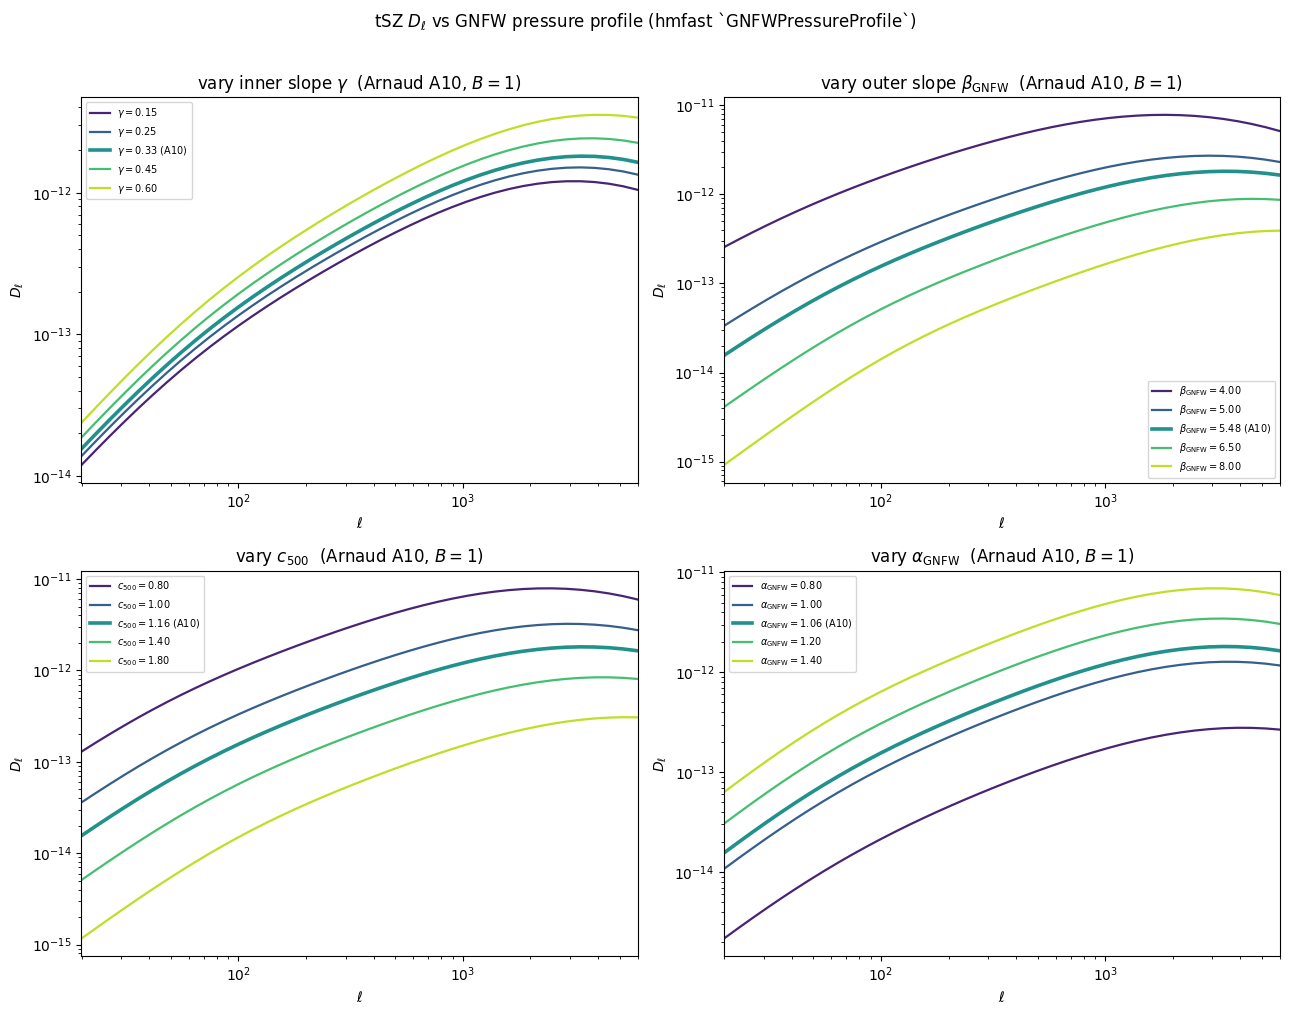

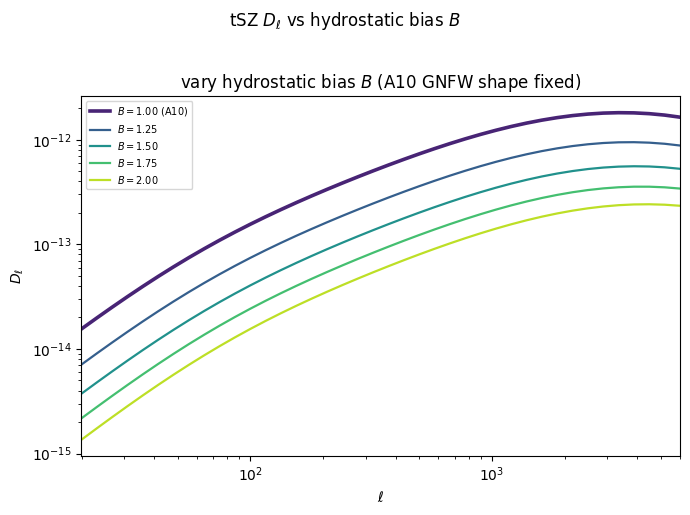

In [3]:
def _plot_panel(ax, curves, title, default_val, fmt="{:.2f}", tag="A10"):
    cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(curves)))
    for col, (val, dl) in zip(cmap, curves.items()):
        is_default = abs(val - default_val) < 1e-3
        ax.plot(ell_np, dl, color=col, lw=2.6 if is_default else 1.6,
                label=fmt.format(val) + (f" ({tag})" if is_default else ""))
    ax.set_title(title)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$D_\ell$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(ell_np.min(), ell_np.max())
    ax.legend(fontsize=7)


fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ref_label = "Arnaud A10, $B=1$"

_plot_panel(axes[0, 0], dl_gamma,
            fr"vary inner slope $\gamma$  ({ref_label})", A10["gamma"], fmt=r"$\gamma={:.2f}$")
_plot_panel(axes[0, 1], dl_beta,
            fr"vary outer slope $\beta_\mathrm{{GNFW}}$  ({ref_label})", A10["beta"],
            fmt=r"$\beta_\mathrm{{GNFW}}={:.2f}$")
_plot_panel(axes[1, 0], dl_c500,
            fr"vary $c_{{500}}$  ({ref_label})", A10["c500"], fmt=r"$c_{{500}}={:.2f}$")
_plot_panel(axes[1, 1], dl_alpha,
            fr"vary $\alpha_\mathrm{{GNFW}}$  ({ref_label})", A10["alpha"],
            fmt=r"$\alpha_\mathrm{{GNFW}}={:.2f}$")

fig.suptitle("tSZ $D_\ell$ vs GNFW pressure profile (hmfast `GNFWPressureProfile`)", y=1.01)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
_plot_panel(ax, dl_B,
            r"vary hydrostatic bias $B$ (A10 GNFW shape fixed)", 1.0, fmt=r"$B={:.2f}$")
fig.suptitle("tSZ $D_\ell$ vs hydrostatic bias $B$", y=1.02)
fig.tight_layout(); plt.show()


## GNFW pressure profile $P(x)$, $x=r/R_{500c}$

Same one-at-a-time shape sweeps as above, now for the **radial profile** itself
(hmfast / Arnaud dimensionless GNFW factor $P_0\,p(x)$ with built-in $P_0$):

$$P(x) = P_0\,(c_{500}x)^{-\gamma}\,
\left[1+(c_{500}x)^{\alpha_\mathrm{GNFW}}\right]^{(\gamma-\beta_\mathrm{GNFW})/\alpha_\mathrm{GNFW}},$$

with $x=r/R_{500c}$. We omit the $P_{500c}(M,z)$ normalization — only the
GNFW **shape** in $x$ is shown (same $P_0$ as the A10 default unless $P_0$ itself were varied).

<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3702865/2475349617.py:46: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle("GNFW $P(x)$ vs scaled radius (same sweeps as $D_\ell$ panels)", y=1.01)


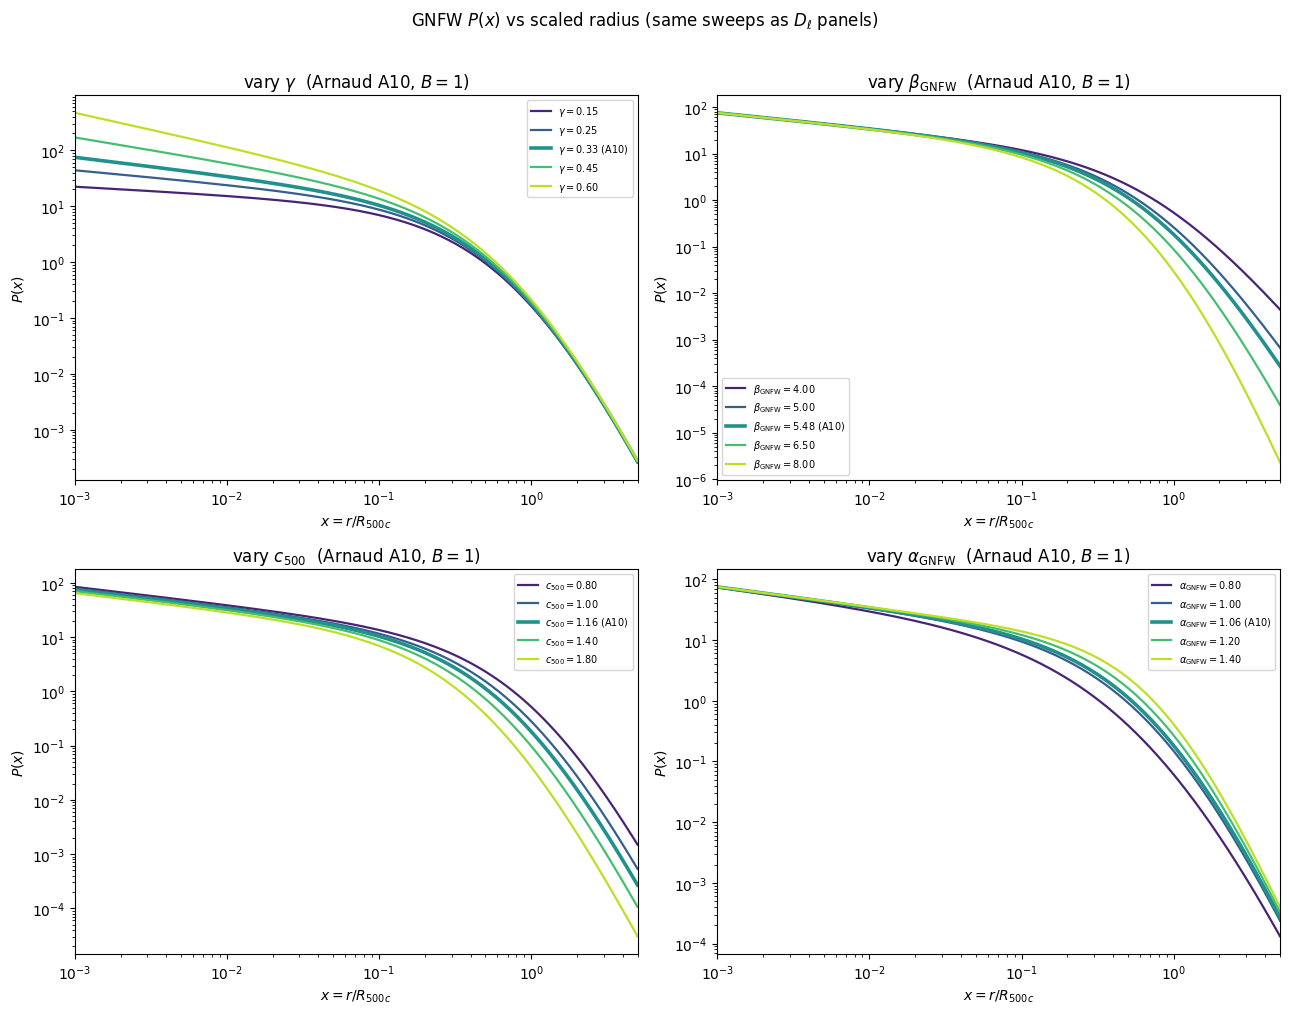

In [4]:
ref_label = "Arnaud A10, $B=1$"

x = np.logspace(-3, np.log10(5.0), 400)


def gnfw_px(x, **gnfw_kw):
    """P(x) = P0 * p(x) in hmfast GNFW convention (no P_500c factor)."""
    p = {**A10, **gnfw_kw}
    cx = p["c500"] * np.maximum(x, 1e-6)
    return p["P0"] * cx ** (-p["gamma"]) * (1.0 + cx ** p["alpha"]) ** (
        (p["gamma"] - p["beta"]) / p["alpha"]
    )


def _plot_px_panel(ax, curves, title, default_val, fmt="{:.2f}", tag="A10"):
    cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(curves)))
    for col, (val, px) in zip(cmap, curves.items()):
        is_default = abs(val - default_val) < 1e-3
        ax.plot(x, px, color=col, lw=2.6 if is_default else 1.6,
                label=fmt.format(val) + (f" ({tag})" if is_default else ""))
    ax.set_title(title)
    ax.set_xlabel(r"$x = r/R_{500c}$")
    ax.set_ylabel(r"$P(x)$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(x.min(), x.max())
    ax.legend(fontsize=7)


px_gamma = {g: gnfw_px(x, gamma=g) for g in GAMMAS}
px_beta = {b: gnfw_px(x, beta=b) for b in BETAS_GNFW}
px_c500 = {c: gnfw_px(x, c500=c) for c in C500S}
px_alpha = {a: gnfw_px(x, alpha=a) for a in ALPHAS_GNFW}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
_plot_px_panel(axes[0, 0], px_gamma,
               fr"vary $\gamma$  ({ref_label})", A10["gamma"], fmt=r"$\gamma={:.2f}$")
_plot_px_panel(axes[0, 1], px_beta,
               fr"vary $\beta_\mathrm{{GNFW}}$  ({ref_label})", A10["beta"],
               fmt=r"$\beta_\mathrm{{GNFW}}={:.2f}$")
_plot_px_panel(axes[1, 0], px_c500,
               fr"vary $c_{{500}}$  ({ref_label})", A10["c500"], fmt=r"$c_{{500}}={:.2f}$")
_plot_px_panel(axes[1, 1], px_alpha,
               fr"vary $\alpha_\mathrm{{GNFW}}$  ({ref_label})", A10["alpha"],
               fmt=r"$\alpha_\mathrm{{GNFW}}={:.2f}$")

fig.suptitle("GNFW $P(x)$ vs scaled radius (same sweeps as $D_\ell$ panels)", y=1.01)
fig.tight_layout(); plt.show()


## Real space: projected Compton-$y$ profile $y(\theta)$

The dimensionless Compton-$y$ at angular separation $\theta$ is obtained by
integrating the hmfast electron-pressure profile $P_e(r)$ along the line of sight,
weighted by the tSZ tracer kernel $W_\mathrm{tSZ}(z)=\sigma_T/(m_ec^2)(1+z)^{-1}$:

$$y(\theta) = W_\mathrm{tSZ}(z)\,2\int_0^{s_\mathrm{max}} P_e\!\left(\sqrt{r_\perp(\theta)^2+s^2}\right)\,ds,$$

with $r_\perp=\theta\,\chi(z)$ (comoving Mpc) and $P_e$ from
`GNFWPressureProfile.u_r`. We use the same pivot halo
$M_{500c}=6\times10^{14}\,M_\odot$, $z=0.1$ as in the $y_\ell$ section; $\theta$ is
plotted in arcminutes.


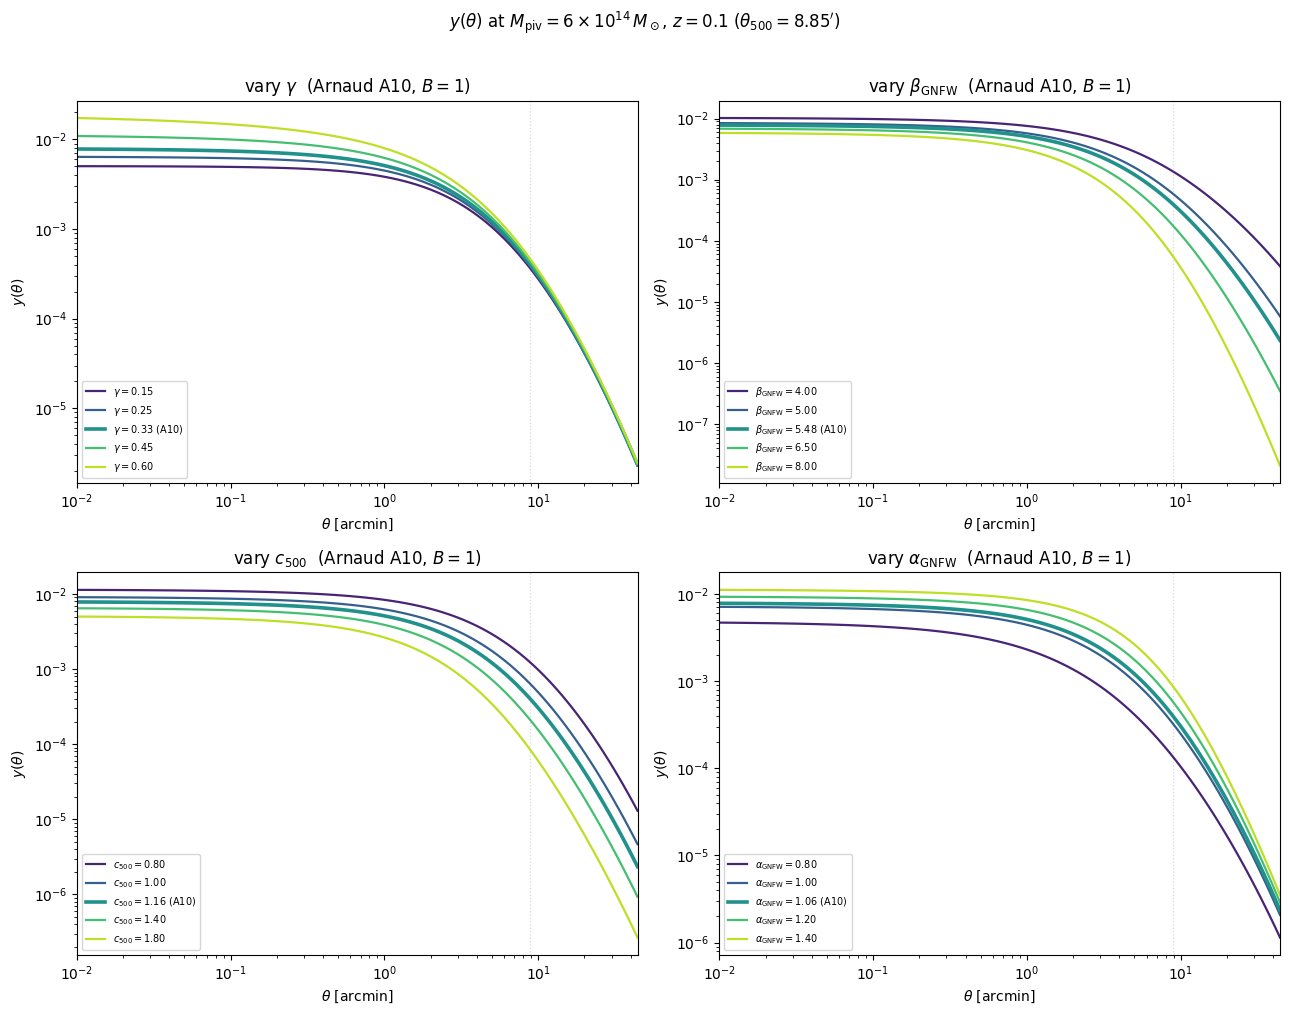

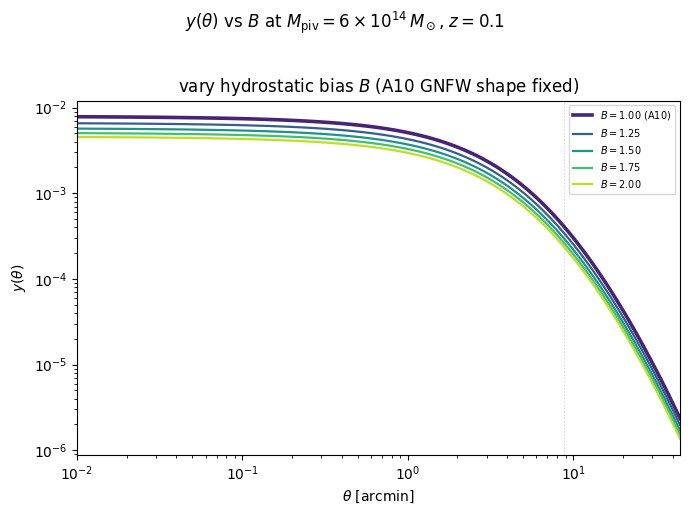

y0 (A10, theta->0): 7.9709e-03
y(theta500) A10: 4.0497e-04


In [5]:
from hmfast.halos import MassDefinition, convert_m_delta
from hmfast.utils import Const

M_PIV = 6.0e14
Z_PIV = 0.1
ref_label = "Arnaud A10, $B=1$"
MPC_CM = Const._Mpc_over_m_ * 100.0

mdef500 = MassDefinition(500, "critical")
c_piv = hm.concentration.c_delta(hm, jnp.array([M_PIV]), jnp.array([Z_PIV]))
m500c_piv = convert_m_delta(COSMO, jnp.array([M_PIV]), jnp.array([Z_PIV]),
                             hm.mass_definition, mdef500, c_old=c_piv)
r500c_piv = float(np.asarray(mdef500.r_delta(COSMO, m500c_piv, Z_PIV)).squeeze())
chi_piv = float(COSMO.angular_diameter_distance(Z_PIV)) * (1.0 + Z_PIV)
theta500_rad = r500c_piv / chi_piv
theta500_arcmin = np.rad2deg(theta500_rad) * 60.0

theta_arcmin = np.logspace(np.log10(0.01), np.log10(5.0 * theta500_arcmin), 120)
s_los = np.linspace(0.0, 5.0 * r500c_piv, 3000)


def y_theta_curve(theta_am, **gnfw_kw):
    """Projected Compton-y y(theta) from hmfast Pe(r) LOS integral."""
    params = {**A10, **gnfw_kw}
    prof = GNFWPressureProfile(**params)
    tr = tSZTracer(profile=prof)
    w = float(np.asarray(tr.kernel(COSMO, Z_PIV)).squeeze())

    theta_rad = np.deg2rad(np.asarray(theta_am, dtype=float) / 60.0)
    r_perp = theta_rad * chi_piv
    r = np.sqrt(r_perp[:, None] ** 2 + s_los[None, :] ** 2)
    Pe = np.asarray(prof.u_r(hm, r.ravel(), jnp.array([M_PIV]), jnp.array([Z_PIV])))
    Pe = Pe[:, 0, 0].reshape(r.shape[0], r.shape[1])
    return w * 2.0 * np.trapezoid(Pe, s_los, axis=1) * MPC_CM


def _plot_ytheta_panel(ax, curves, title, default_val, fmt="{:.2f}", tag="A10"):
    cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(curves)))
    for col, (val, yt) in zip(cmap, curves.items()):
        is_default = abs(val - default_val) < 1e-3
        ax.plot(theta_arcmin, yt, color=col, lw=2.6 if is_default else 1.6,
                label=fmt.format(val) + (f" ({tag})" if is_default else ""))
    ax.axvline(theta500_arcmin, color="0.85", ls=":", lw=0.9, zorder=0)
    ax.set_title(title)
    ax.set_xlabel(r"$\theta$ [arcmin]")
    ax.set_ylabel(r"$y(\theta)$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(theta_arcmin.min(), theta_arcmin.max())
    ax.legend(fontsize=7)


yt_gamma = {g: y_theta_curve(theta_arcmin, gamma=g) for g in GAMMAS}
yt_beta = {b: y_theta_curve(theta_arcmin, beta=b) for b in BETAS_GNFW}
yt_c500 = {c: y_theta_curve(theta_arcmin, c500=c) for c in C500S}
yt_alpha = {a: y_theta_curve(theta_arcmin, alpha=a) for a in ALPHAS_GNFW}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
_plot_ytheta_panel(axes[0, 0], yt_gamma,
                   fr"vary $\gamma$  ({ref_label})", A10["gamma"], fmt=r"$\gamma={:.2f}$")
_plot_ytheta_panel(axes[0, 1], yt_beta,
                   fr"vary $\beta_\mathrm{{GNFW}}$  ({ref_label})", A10["beta"],
                   fmt=r"$\beta_\mathrm{{GNFW}}={:.2f}$")
_plot_ytheta_panel(axes[1, 0], yt_c500,
                   fr"vary $c_{{500}}$  ({ref_label})", A10["c500"], fmt=r"$c_{{500}}={:.2f}$")
_plot_ytheta_panel(axes[1, 1], yt_alpha,
                   fr"vary $\alpha_\mathrm{{GNFW}}$  ({ref_label})", A10["alpha"],
                   fmt=r"$\alpha_\mathrm{{GNFW}}={:.2f}$")
fig.suptitle(fr"$y(\theta)$ at $M_\mathrm{{piv}}=6\times10^{{14}}\,M_\odot$, $z={Z_PIV}$ "
             fr"($\theta_{{500}}={theta500_arcmin:.2f}'$)", y=1.01)
fig.tight_layout(); plt.show()

yt_B = {b: y_theta_curve(theta_arcmin, B=b) for b in BS}
fig, ax = plt.subplots(figsize=(7, 5))
_plot_ytheta_panel(ax, yt_B,
                   r"vary hydrostatic bias $B$ (A10 GNFW shape fixed)", 1.0, fmt=r"$B={:.2f}$")
fig.suptitle(fr"$y(\theta)$ vs $B$ at $M_\mathrm{{piv}}=6\times10^{{14}}\,M_\odot$, $z={Z_PIV}$", y=1.02)
fig.tight_layout(); plt.show()

a10_y0 = float(y_theta_curve([0.001], **A10)[0])
print(f"y0 (A10, theta->0): {a10_y0:.4e}")
print(f"y(theta500) A10: {float(np.interp(theta500_arcmin, theta_arcmin, yt_gamma[A10['gamma']])):.4e}")


## Fourier / multipole space: $u_\ell$ and $y_\ell$

hmfast Hankel-transforms the real-space electron pressure $P_e(r)$ from
`GNFWPressureProfile.u_r` and returns the Limber-projected harmonic
$u_\ell(M,z)$ via `profile.u_k` (despite the name, it interpolates onto
$\ell=(k+\tfrac12)\chi$). For the tSZ tracer,

$$y_\ell(M,z) = W_\mathrm{tSZ}(z)\,u_\ell(M,z),\qquad
W_\mathrm{tSZ}=\frac{\sigma_T}{m_ec^2}\frac{1}{1+z}.$$

Below we evaluate $y_\ell$ at a pivot halo $M_{500c}=6\times10^{14}\,M_\odot$,
$z=0.1$, with the same one-at-a-time GNFW shape sweeps. Vertical ticks mark
$\ell=500,2000,3000$.


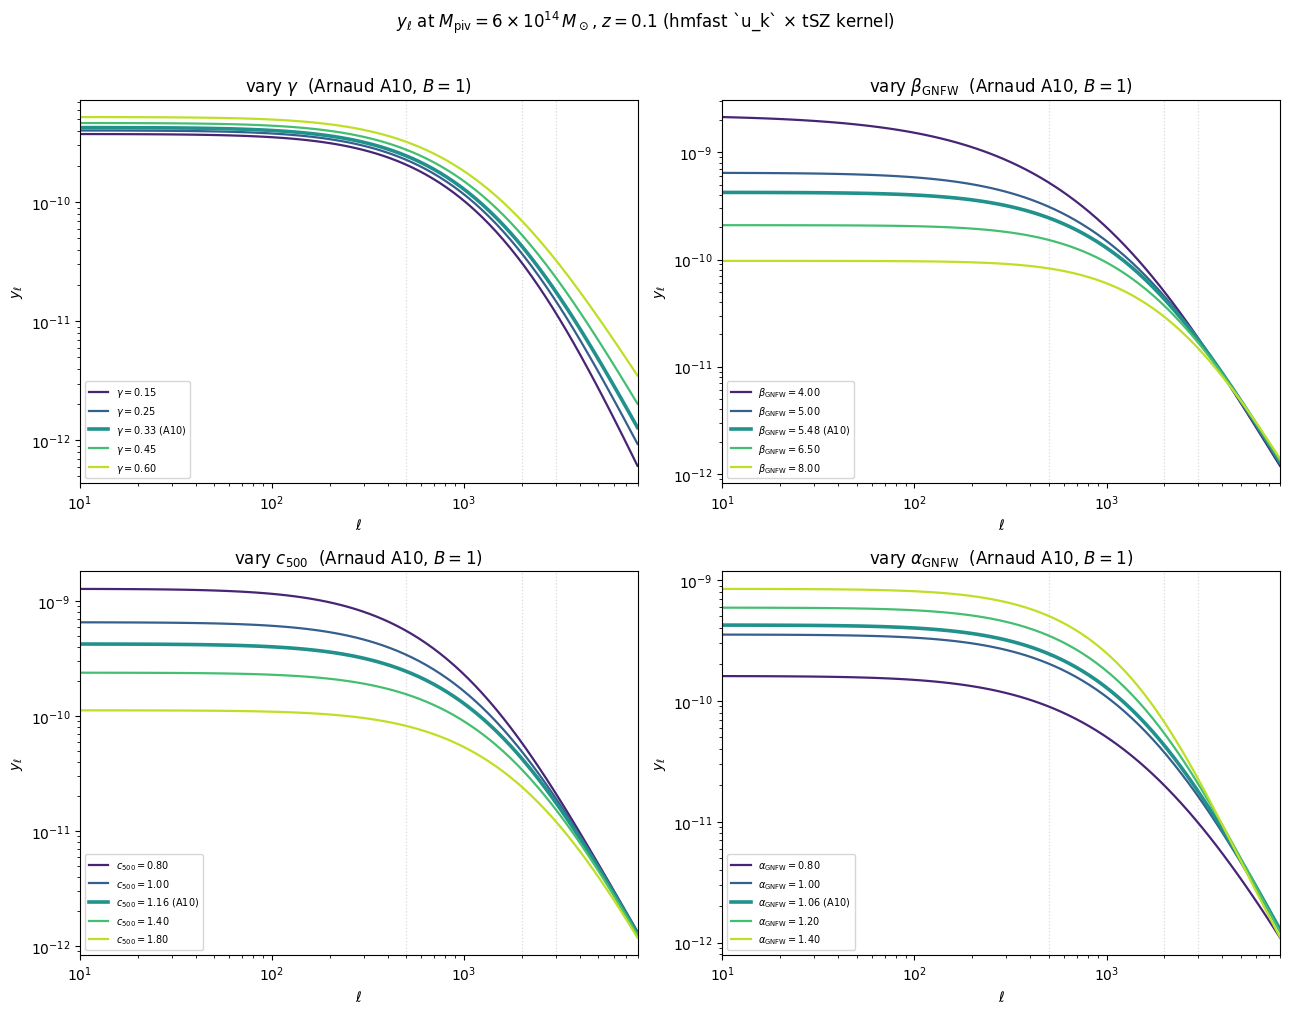

y_ell at marked ell (A10): {500: 2.4513552791213594e-10, 2000: 4.2901226299474594e-11, 3000: 1.789760472321049e-11}


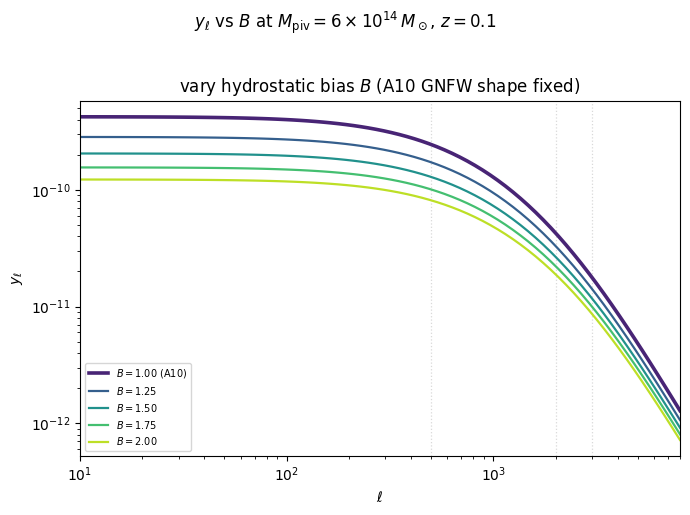

y_ell at marked ell vs B (A10 shape):
  B=1.00: {500: 2.4513552791213594e-10, 2000: 4.2901226299474594e-11, 3000: 1.789760472321049e-11}
  B=1.25: {500: 1.725461930329387e-10, 2000: 3.3186671970259356e-11, 3000: 1.4273854307527749e-11}
  B=1.50: {500: 1.2917753444235848e-10, 2000: 2.679863876545178e-11, 3000: 1.1819303847082282e-11}
  B=1.75: {500: 1.0095591791203269e-10, 2000: 2.2293028265319982e-11, 3000: 1.0048407590968388e-11}
  B=2.00: {500: 8.144282471806843e-11, 2000: 1.8966303023334958e-11, 3000: 8.709618617852135e-12}


In [6]:
M_PIV = 6.0e14
Z_PIV = 0.1
ELL_MARKS = [500, 2000, 3000]
ref_label = "Arnaud A10, $B=1$"

ell_u = jnp.logspace(1.0, np.log10(8000), 80)
ell_u_np = np.asarray(ell_u)
chi_piv = float(COSMO.angular_diameter_distance(Z_PIV)) * (1.0 + Z_PIV)
k_u = (ell_u + 0.5) / chi_piv


def y_ell_curve(**gnfw_kw):
    """Single-halo Compton-y multipoles y_l = W_tsz * u_l (hmfast)."""
    params = {**A10, **gnfw_kw}
    prof = GNFWPressureProfile(**params)
    tr = tSZTracer(profile=prof)
    u = np.asarray(prof.u_k(hm, k_u, jnp.array([M_PIV]), jnp.array([Z_PIV])))[:, 0, 0]
    w = float(np.asarray(tr.kernel(COSMO, Z_PIV)).squeeze())
    return w * u


def _plot_yell_panel(ax, curves, title, default_val, fmt="{:.2f}", tag="A10"):
    cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(curves)))
    for col, (val, yl) in zip(cmap, curves.items()):
        is_default = abs(val - default_val) < 1e-3
        ax.plot(ell_u_np, yl, color=col, lw=2.6 if is_default else 1.6,
                label=fmt.format(val) + (f" ({tag})" if is_default else ""))
    for em in ELL_MARKS:
        ax.axvline(em, color="0.85", ls=":", lw=0.9, zorder=0)
    ax.set_title(title)
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$y_\ell$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(ell_u_np.min(), ell_u_np.max())
    ax.legend(fontsize=7)


yl_gamma = {g: y_ell_curve(gamma=g) for g in GAMMAS}
yl_beta = {b: y_ell_curve(beta=b) for b in BETAS_GNFW}
yl_c500 = {c: y_ell_curve(c500=c) for c in C500S}
yl_alpha = {a: y_ell_curve(alpha=a) for a in ALPHAS_GNFW}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
_plot_yell_panel(axes[0, 0], yl_gamma,
                 fr"vary $\gamma$  ({ref_label})", A10["gamma"], fmt=r"$\gamma={:.2f}$")
_plot_yell_panel(axes[0, 1], yl_beta,
                 fr"vary $\beta_\mathrm{{GNFW}}$  ({ref_label})", A10["beta"],
                 fmt=r"$\beta_\mathrm{{GNFW}}={:.2f}$")
_plot_yell_panel(axes[1, 0], yl_c500,
                 fr"vary $c_{{500}}$  ({ref_label})", A10["c500"], fmt=r"$c_{{500}}={:.2f}$")
_plot_yell_panel(axes[1, 1], yl_alpha,
                 fr"vary $\alpha_\mathrm{{GNFW}}$  ({ref_label})", A10["alpha"],
                 fmt=r"$\alpha_\mathrm{{GNFW}}={:.2f}$")

fig.suptitle(fr"$y_\ell$ at $M_\mathrm{{piv}}=6\times10^{{14}}\,M_\odot$, $z={Z_PIV}$ "
             r"(hmfast `u_k` $\times$ tSZ kernel)", y=1.01)
fig.tight_layout(); plt.show()

a10_y = yl_gamma[A10["gamma"]]
print("y_ell at marked ell (A10):",
      {em: float(np.interp(em, ell_u_np, a10_y)) for em in ELL_MARKS})

yl_B = {b: y_ell_curve(B=b) for b in BS}

fig, ax = plt.subplots(figsize=(7, 5))
_plot_yell_panel(ax, yl_B,
                 r"vary hydrostatic bias $B$ (A10 GNFW shape fixed)", 1.0, fmt=r"$B={:.2f}$")
fig.suptitle(fr"$y_\ell$ vs $B$ at $M_\mathrm{{piv}}=6\times10^{{14}}\,M_\odot$, $z={Z_PIV}$", y=1.02)
fig.tight_layout(); plt.show()

print("y_ell at marked ell vs B (A10 shape):")
for b in BS:
    y = yl_B[b]
    print(f"  B={b:.2f}:", {em: float(np.interp(em, ell_u_np, y)) for em in ELL_MARKS})


### Trends

- **Inner slope $\gamma$** (top left): controls the central pressure cusp.
  Steeper cores ($\gamma\uparrow$) concentrate emission in the inner beam,
  boosting high-$\ell$ power relative to the large-scale tail.
- **Outer slope $\beta_\mathrm{GNFW}$** (top right): sets how quickly pressure
  falls beyond $R_{500c}$. A shallower outer slope keeps more extended emission,
  reddening the spectrum (more low-$\ell$ power).
- **Concentration $c_{500}$** (bottom left): rescales the dimensionless radius
  in $p(x)$; higher $c_{500}$ compresses the profile in physical units for a
  fixed $R_{500c}$, sharpening the projected signal.
- **Transition exponent $\alpha_\mathrm{GNFW}$** (bottom right): governs how
  sharply the profile turns over from the inner power law to the outer slope.
- The hmfast built-in $P_{500c}(M,z)$ normalization is unchanged across curves;
  only one GNFW shape parameter varies at a time around the A10 defaults.
### $P(x)$ panels

- **$\gamma$**: steepens the inner cusp as $\gamma\uparrow$ ($P\propto x^{-\gamma}$ for $c_{500}x\ll1$).
- **$\beta_\mathrm{GNFW}$**: sets the large-$x$ power-law tail ($P\propto x^{-\beta_\mathrm{GNFW}}$ for $c_{500}x\gg1$).
- **$c_{500}$**: shifts the turnover radius in $x$ space ($c_{500}x=1$); higher $c_{500}$ moves the bump to smaller $x$.
- **$\alpha_\mathrm{GNFW}$**: controls how sharply the profile transitions between the inner and outer slopes.

### $y_\ell$ panels

- $y_\ell$ is the **single-halo** Compton-$y$ harmonic that hmfast feeds into the 1-halo term ($\propto y_\ell^2$ after the mass function integral).
- Shape changes that extend $P(x)$ outward (low $\beta_\mathrm{GNFW}$, low $c_{500}$) boost $y_\ell$ at **low $\ell$**; sharper cores raise **high-$\ell$** $y_\ell$.
- The dotted vertical lines at $\ell=500,2000,3000$ match common tSZ comparison multipoles.

### Hydrostatic bias $B$ panels

- With A10 GNFW **shape** fixed, $B$ enters only through the Arnaud $P_{500c}(M,z)$ normalization ($\propto (M_{500c}/B)^{2/3+0.12}$).
- Higher $B$ lowers the pressure normalization at fixed catalogue mass, suppressing both $D_\ell$ and $y_\ell$ with little change to the spectral **shape**.

### $y(\theta)$ panels

- $y(\theta)$ is the **projected** Compton-$y$ from a symmetric line-of-sight integral of hmfast $P_e(r)$, using the same pivot halo as the $y_\ell$ panels.
- Shape parameters that broaden $P(x)$ (low $\beta_\mathrm{GNFW}$, low $c_{500}$) raise $y(\theta)$ in the outskirts; steeper cores ($\gamma\uparrow$) sharpen the central peak.
- The dotted vertical line marks $\theta_{500}$; $B$ mainly rescales the overall amplitude through $P_{500c}$.
